### LISTA 1 
Generowanie zmiennych losowych, dystrybuanta, gęstość, estymator jądrowy, skośność, kurtoza, generowanie próbek 2 wymiarowych: (1000, 1000)

In [87]:
import numpy as np
import scipy.stats as sc
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.distributions.empirical_distribution import ECDF

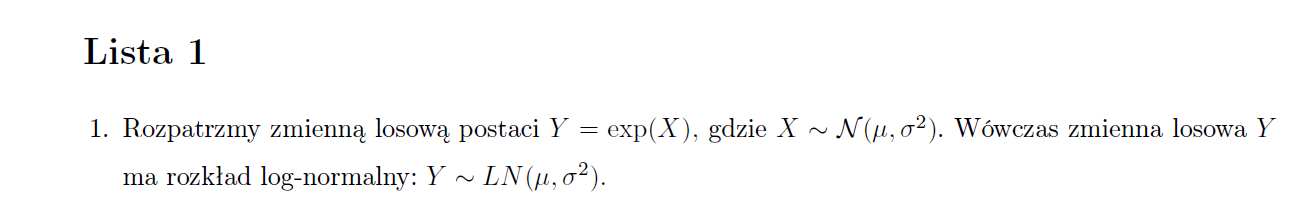

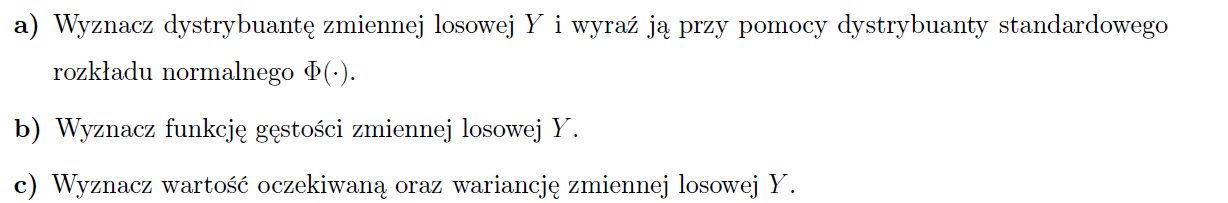

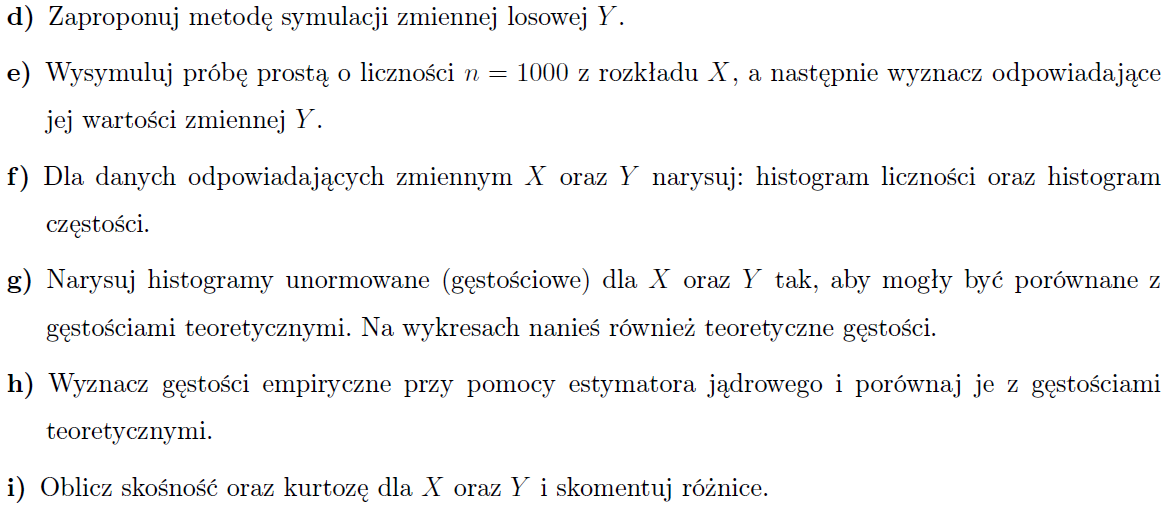

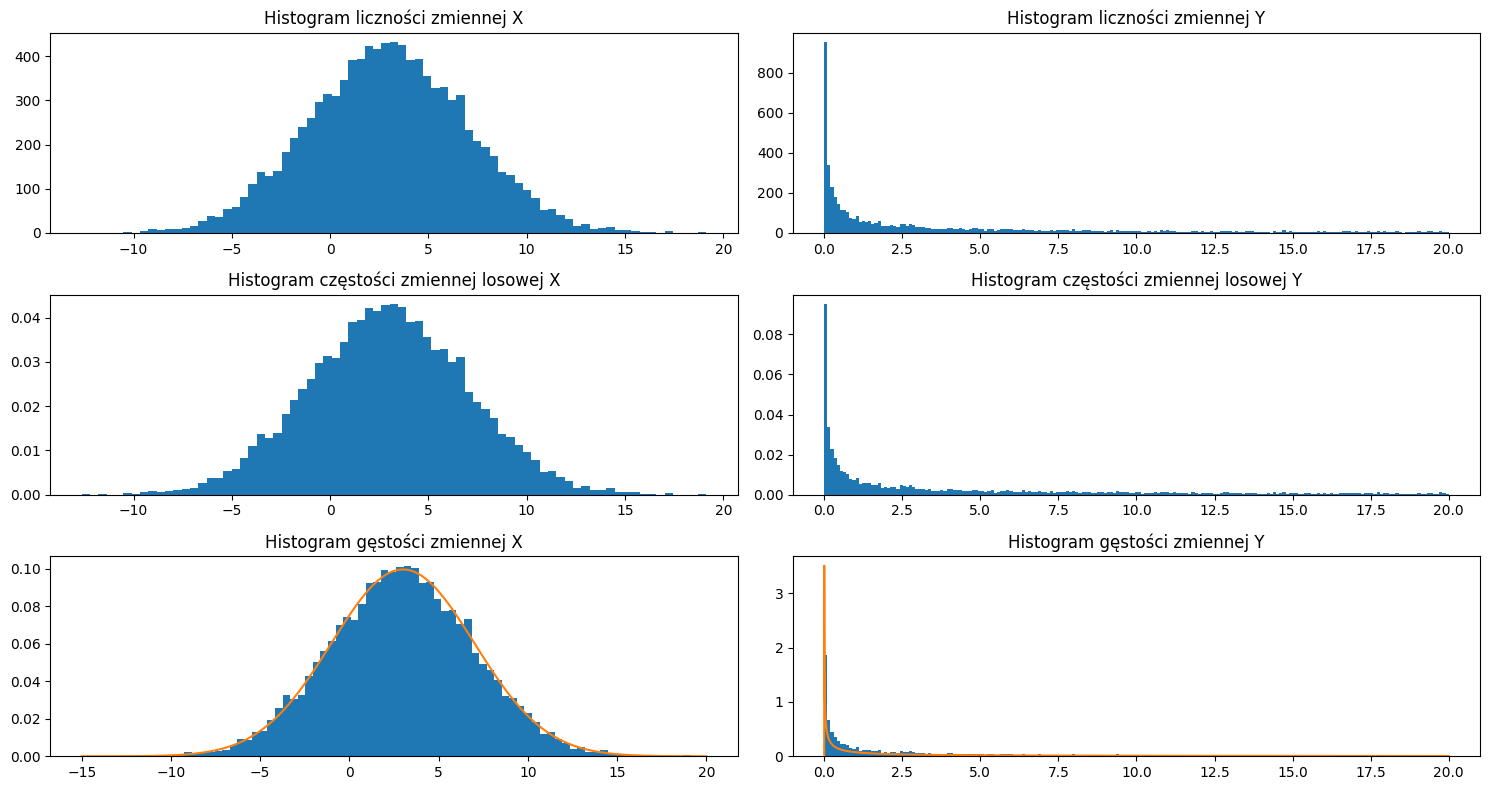

In [88]:
mi = 3
sigma2 = 4
N = 10000
X = np.random.normal(mi, sigma2, size=N)
Y = np.e**X



fig, axs = plt.subplots(3, 2, figsize=(15, 8))
axs[0, 0].hist(X, bins=75)
axs[0, 0].set_title('Histogram liczności zmiennej X')
axs[0, 1].hist(Y, bins=np.linspace(0, 20, 200))
axs[0, 1].set_title('Histogram liczności zmiennej Y')
                    
axs[1, 0].hist(X, bins=75, weights=np.ones(N) / N)
axs[1, 0].set_title(f'Histogram częstości zmiennej losowej X')
axs[1, 1].hist(Y, bins=np.linspace(0, 20, 200), weights=np.ones(N) / N)
axs[1, 1].set_title(f'Histogram częstości zmiennej losowej Y')

x = np.linspace(-15, 20, N)
y = np.linspace(0, 20, N)

axs[2, 0].hist(X, bins=75, density=True)
axs[2, 0].plot(x, sc.norm.pdf(x, mi, sigma2))

axs[2, 0].set_title('Histogram gęstości zmiennej X')
axs[2, 1].hist(Y, bins=np.linspace(0, 20, 200), density=True)
axs[2, 1].plot(y, sc.lognorm.pdf(y, scale=np.exp(mi), s=sigma2))
axs[2, 1].set_title('Histogram gęstości zmiennej Y')
plt.tight_layout()
plt.show()

### ESTYMATOR JĄDROWY


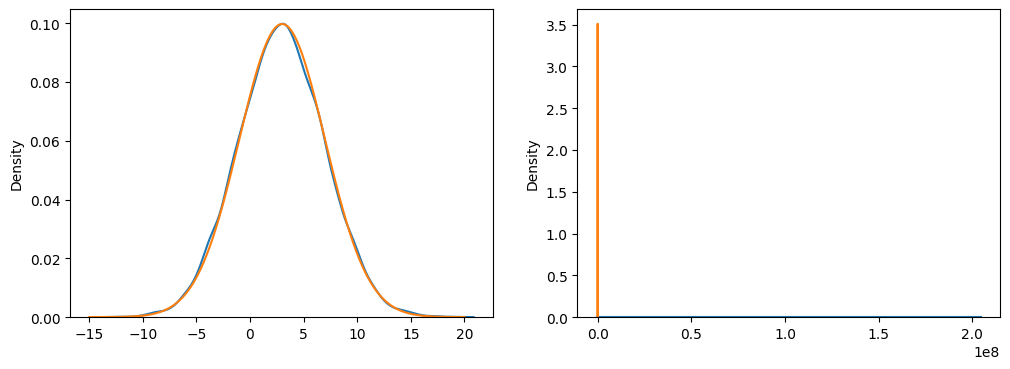

In [89]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(X, ax=axs[0], bw_adjust=0.9)
axs[0].plot(x, sc.norm.pdf(x, mi, sigma2))
sns.kdeplot(Y, ax=axs[1], bw_adjust=0.5)
axs[1].plot(y, sc.lognorm.pdf(y, scale=np.exp(mi), s=sigma2))

plt.show()

In [90]:
skewx = sc.skew(X)
skewy = sc.skew(Y)

print(f'Skew of X: {skewx}, kurtosis: {sc.kurtosis(X)}')
print(f'Skew of Y: {skewy}, kurtosis: {sc.kurtosis(Y)}')

Skew of X: 0.03137353573278889, kurtosis: 0.03578792275002263
Skew of Y: 66.78443027113673, kurtosis: 4829.292161154404


### ZADANIE 2 -ROZKŁAD PARETO

empiryczna dystrybuanta:

from statsmodels.distributions.empirical_distribution import ECDF

ecdf = ECDF(data)

plt.step(x, ecdf(x))

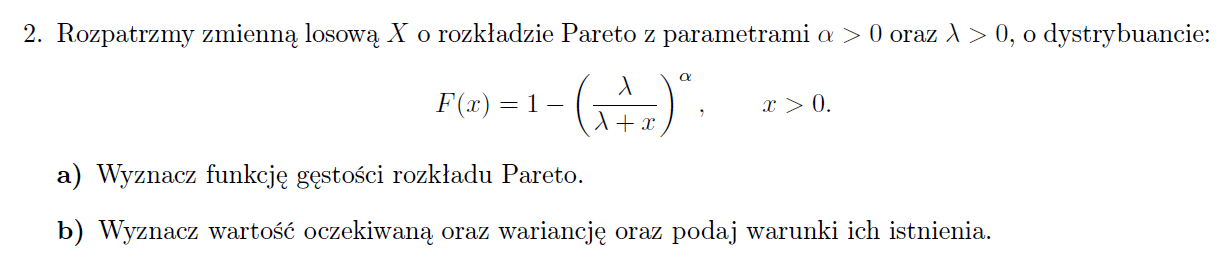

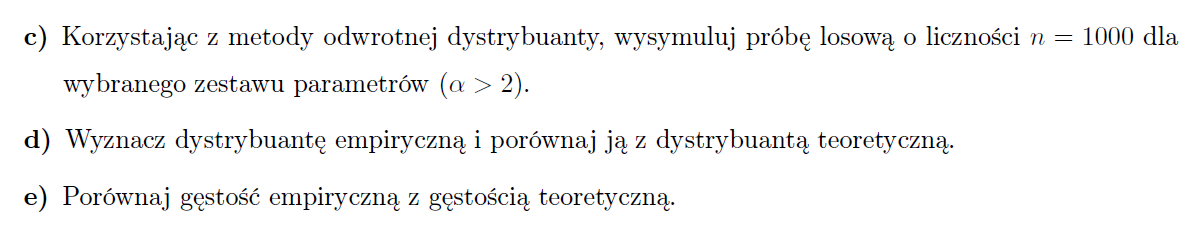

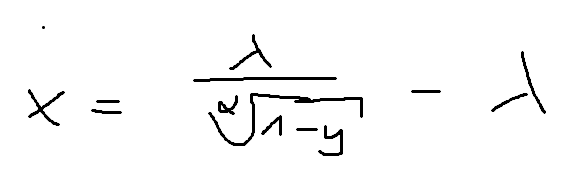

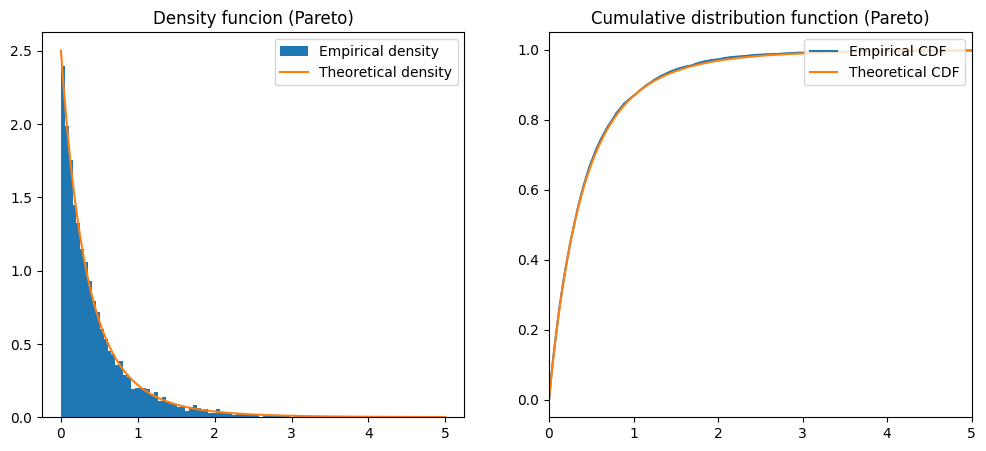

In [ ]:
N = 10000
U = np.random.random(N)
lam = 2
alfa = 5
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

Pareto = lam/( (1 - U)**(1/alfa)) - lam
axs[0].hist(Pareto, bins=np.linspace(0, 5, 100),density=True, label='Empirical density')
axs[0].set_title('Density funcion (Pareto)')
x = np.linspace(0, 5, N)
y = sc.lomax.pdf(x, loc=0, scale=lam, c=alfa)

axs[0].plot(x, y, label='Theoretical density')
ecdf = ECDF(Pareto) # ewentulnie sns.ecdfplot()
axs[1].step(ecdf.x, ecdf.y, where='post', label='Empirical CDF')
ParetoCDF = sc.lomax.cdf(x, loc=0, scale=lam, c=alfa)
axs[1].plot(x, ParetoCDF, label='Theoretical CDF')
axs[1].set_xlim(0, 5)
axs[1].set_title('Cumulative distribution function (Pareto)')

axs[0].legend(loc='upper right')
axs[1].legend(loc='upper right')
plt.show()

In [ ]:
alfa_set = np.arange(4.01, 40, 2)
## ma sens dopiero dla alfa > 4
for alfa in alfa_set:
    y = sc.lomax.rvs(loc=0, scale=lam, c=alfa, size=(1000, 1000))
    kurt = sc.kurtosis(y, axis=1)
    var_kurt = round(np.var(kurt), 2)
    print(f'Alfa={round(alfa, 1)}, kurtosis = {np.round(np.mean(kurt), 2)}, variance = {var_kurt}')

Alfa=4.0, kurtosis = 44.69, variance = 3372.34
Alfa=6.0, kurtosis = 22.36, variance = 704.63
Alfa=8.0, kurtosis = 15.56, variance = 185.28
Alfa=10.0, kurtosis = 12.49, variance = 95.37
Alfa=12.0, kurtosis = 11.11, variance = 53.0
Alfa=14.0, kurtosis = 10.36, variance = 58.01
Alfa=16.0, kurtosis = 9.28, variance = 24.05
Alfa=18.0, kurtosis = 9.17, variance = 56.84
Alfa=20.0, kurtosis = 8.21, variance = 16.85
Alfa=22.0, kurtosis = 8.15, variance = 17.81
Alfa=24.0, kurtosis = 8.07, variance = 23.42
Alfa=26.0, kurtosis = 7.6, variance = 16.32
Alfa=28.0, kurtosis = 7.61, variance = 18.32
Alfa=30.0, kurtosis = 7.26, variance = 12.21
Alfa=32.0, kurtosis = 7.38, variance = 19.95
Alfa=34.0, kurtosis = 7.07, variance = 12.6
Alfa=36.0, kurtosis = 7.15, variance = 10.31
Alfa=38.0, kurtosis = 7.0, variance = 10.94
